In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit

In [4]:
data = pd.read_csv('Titanic-Dataset.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
split= StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for train_index, test_index in split.split(data, data[['Survived','Pclass','Sex']]):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

<Axes: >

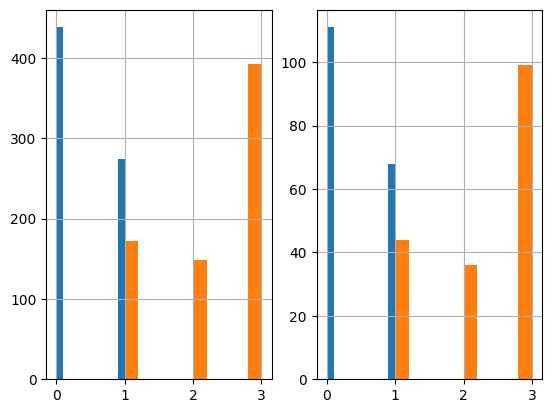

In [29]:
plt.subplot(1,2,1)
strat_train_set['Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot(1,2,2)
strat_test_set['Survived'].hist()
strat_test_set['Pclass'].hist()

In [11]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 7 to 732
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          578 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        171 non-null    object 
 11  Embarked     711 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [24]:
from sklearn.base import BaseEstimator , TransformerMixin 
from sklearn.impute import SimpleImputer

class AgeImputer(BaseEstimator ,TransformerMixin):

    def fit(self,X,y=None):
        return self
    
    def transform(self,X):
        imputer = SimpleImputer(strategy='mean')
        X['Age'] = imputer.fit_transform(X[['Age']])
        return X

In [25]:
from sklearn.preprocessing import OneHotEncoder

class Encoder(BaseEstimator  , TransformerMixin):

    def fit(self,X,y=None):
        return self
    
    def transform(self,X):
        encoder = OneHotEncoder()
        matrix = encoder.fit_transform(X[['Embarked']]).toarray()
        Column_names = ['C','S','Q',"N"]

        for i in range(len(matrix[0])):
            X[Column_names[i]] = matrix.T[i]

        matrix = encoder.fit_transform(X[['Sex']]).toarray()
        Column_names = ['Male','Female']    
        for i in range(len(matrix[0])):
            X[Column_names[i]] = matrix.T[i]  
              
        return X
        

In [26]:
class featureDropper(BaseEstimator , TransformerMixin):

    def fit(self,X,y=None):
        return self
    
    def transform(self,X):
        return X.drop(['PassengerId','Name','Ticket','Cabin','Sex','N',"Embarked"],axis=1,errors='ignore')

In [27]:
from sklearn.pipeline import Pipeline 

pipeline = Pipeline([('ageimputer',AgeImputer()),('encoder',Encoder()),('featuredropper',featureDropper())])

In [30]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [31]:
strat_train_set

,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Male,Female
138,0,3,16.000000,0,0,9.2167,0.0,0.0,1.0,0.0,1.0
456,0,1,65.000000,0,0,26.5500,0.0,0.0,1.0,0.0,1.0
128,1,3,29.466989,1,1,22.3583,1.0,0.0,0.0,1.0,0.0
40,0,3,40.000000,1,0,9.4750,0.0,0.0,1.0,1.0,0.0
675,0,3,18.000000,0,0,7.7750,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
164,0,3,1.000000,4,1,39.6875,0.0,0.0,1.0,0.0,1.0
553,1,3,22.000000,0,0,7.2250,1.0,0.0,0.0,0.0,1.0
212,0,3,22.000000,0,0,7.2500,0.0,0.0,1.0,0.0,1.0
100,0,3,28.000000,0,0,7.8958,0.0,0.0,1.0,1.0,0.0


In [32]:
from sklearn.preprocessing import StandardScaler

X=strat_train_set.drop(['Survived'],axis=1)
y=strat_train_set['Survived']

scaler=StandardScaler()
X_data = scaler.fit_transform(X)  
y_data = y.to_numpy()